# Restauración y algoritmos de inpainting

**Duración estimada:** 90 minutos

## Objetivo

En este cuaderno vas a trabajar con una imagen real y una máscara de daño construida de forma controlada para entender cómo funcionan los algoritmos de **inpainting** de OpenCV. El foco está en usar la misma máscara para pedirle al sistema que reconstruya zonas faltantes o rayadas.

## Resultados de aprendizaje

Al final de este cuaderno vas a poder:

- explicar qué problema resuelve `cv2.inpaint`;
- preparar una máscara binaria de daño para alimentar el algoritmo;
- comparar los métodos `cv2.INPAINT_TELEA` y `cv2.INPAINT_NS`;
- analizar qué parte del fondo fue reconstruida de forma plausible y qué parte quedó artificial;
- relacionar estas técnicas con un pipeline de restauración fotográfica.

## Relación con cuadernos anteriores

Este cuaderno se apoya directamente en `006b - filtros de suavizado y reduccion de ruido.ipynb` y `006c - morfologia matematica para limpieza de mascaras.ipynb`. Primero limpiamos ruido, después limpiamos máscaras y ahora usamos una máscara de daño para reconstruir imagen.


## 1. Concepto: restaurar no es simplemente “tapar”

El inpainting intenta rellenar una región faltante usando la información del contexto vecino. Eso quiere decir que el algoritmo **no conoce** el contenido original perdido: lo infiere a partir de bordes, texturas y continuidad local.

En términos intuitivos:

- `INPAINT_TELEA` suele propagar información cercana de manera rápida y efectiva;
- `INPAINT_NS` sigue una lógica inspirada en continuidad de estructuras y flujo de información, tomada de una intuición ligada a Navier-Stokes.

Ninguno de los dos “recuerda” la imagen original. Los dos producen una hipótesis razonable.

[Pregunta para pensar]

Si una restauración digital completa una parte perdida de una foto, ¿estamos recuperando memoria visual o estamos generando una versión probable de esa memoria?


In [1]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


CARPETA_IMAGENES = Path("Imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)

URL_IMAGEN = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/building.jpg"
RUTA_IMAGEN = CARPETA_IMAGENES / "building.jpg"


def descargar_imagen_si_falta(url, ruta_local):
    '''Descarga una imagen de referencia solo si todavía no existe en disco.'''
    if ruta_local.exists():
        print(f"La imagen ya estaba disponible en: {ruta_local}")
        return

    print("La imagen no estaba en la carpeta local. La descargamos ahora.")
    urllib.request.urlretrieve(url, ruta_local)
    print(f"Imagen descargada en: {ruta_local}")


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    '''Muestra una imagen con ejes visibles para leer coordenadas.'''
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(40, ancho // 6)
    paso_y = max(40, alto // 5)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(16, 5)):
    '''Muestra varias imágenes lado a lado manteniendo ejes visibles.'''
    if mapas is None:
        mapas = [None] * len(imagenes)

    figura, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def recortar_region(imagen, x_inicio, y_inicio, ancho, alto):
    '''Devuelve un recorte rectangular para observar detalle local.'''
    return imagen[y_inicio:y_inicio + alto, x_inicio:x_inicio + ancho]


def crear_mascara_de_rayones(imagen_rgb):
    '''Crea una máscara binaria con rayones y marcas sintéticas sobre una imagen real.'''
    alto, ancho = imagen_rgb.shape[:2]
    mascara = np.zeros((alto, ancho), dtype=np.uint8)

    # Rayones diagonales finos y gruesos.
    cv2.line(mascara, (120, 50), (300, 340), 255, 5)
    cv2.line(mascara, (230, 30), (420, 280), 255, 3)
    cv2.line(mascara, (470, 70), (700, 310), 255, 4)

    # Pequeñas roturas o manchas alargadas.
    cv2.ellipse(mascara, (330, 240), (22, 10), 15, 0, 360, 255, -1)
    cv2.ellipse(mascara, (560, 210), (26, 12), -20, 0, 360, 255, -1)

    # Texto superpuesto como daño intencional.
    cv2.putText(
        mascara,
        "Archivo",
        (180, 140),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        255,
        3,
        cv2.LINE_AA,
    )
    return mascara


def superponer_dano(imagen_rgb, mascara_dano):
    '''Dibuja el daño sobre la imagen para simular una copia deteriorada.'''
    imagen_danada = imagen_rgb.copy()
    imagen_danada[mascara_dano == 255] = [245, 245, 245]
    return imagen_danada


def calcular_error_medio_absoluto(imagen_referencia, imagen_prueba):
    '''Calcula una medida simple de distancia entre dos imágenes RGB.'''
    diferencia = np.abs(imagen_referencia.astype(np.float32) - imagen_prueba.astype(np.float32))
    return diferencia.mean()


descargar_imagen_si_falta(URL_IMAGEN, RUTA_IMAGEN)


La imagen ya estaba disponible en: Imagenes\building.jpg


## 2. Ejercicio guiado: partir de una imagen real y construir una máscara de daño

Vamos a usar una fotografía real de una fachada. Tiene líneas arquitectónicas claras, superficies relativamente suaves y zonas con textura. Eso la vuelve muy útil para ver cuándo la reconstrucción respeta bordes y cuándo empieza a inventar demasiado.

Primero vamos a abrir la imagen y después vamos a construir una máscara de daño sintética sobre esa imagen real. Así tenemos una situación controlada: conocemos el original y podemos comparar contra él.


Forma de la imagen: (600, 868, 3)


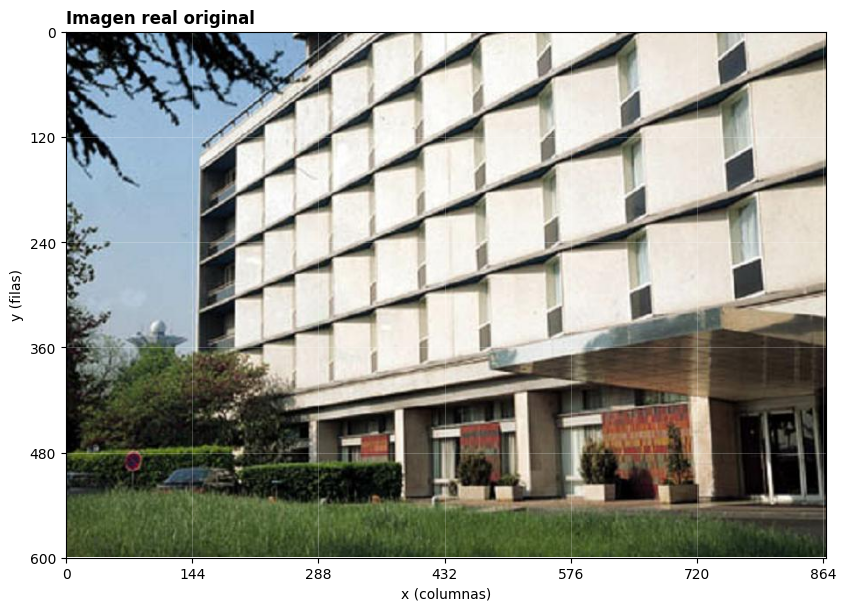

In [2]:
imagen_bgr = cv2.imread(str(RUTA_IMAGEN), cv2.IMREAD_COLOR)
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

print("Forma de la imagen:", imagen_rgb.shape)

mostrar_varias_imagenes(
    [imagen_rgb],
    ["Imagen real original"],
    tamano=(9, 6),
)


**Qué observar**

- Hay bordes rectos, ventanas, zonas claras y sombras.
- Algunas partes son fáciles de prolongar visualmente; otras no tanto.

**Qué conclusión podés sacar**

- Esta imagen es buena para probar inpainting porque combina regiones regulares y regiones más difíciles.

**Qué limitación tiene este punto de partida**

- Aunque la imagen es real, el daño todavía no existe. Lo vamos a agregar de manera artificial para poder medir mejor qué recupera cada método.


Ahora vamos a construir una máscara binaria de rayones y marcas superpuestas. Después vamos a usar esa misma máscara para generar una versión dañada de la foto.


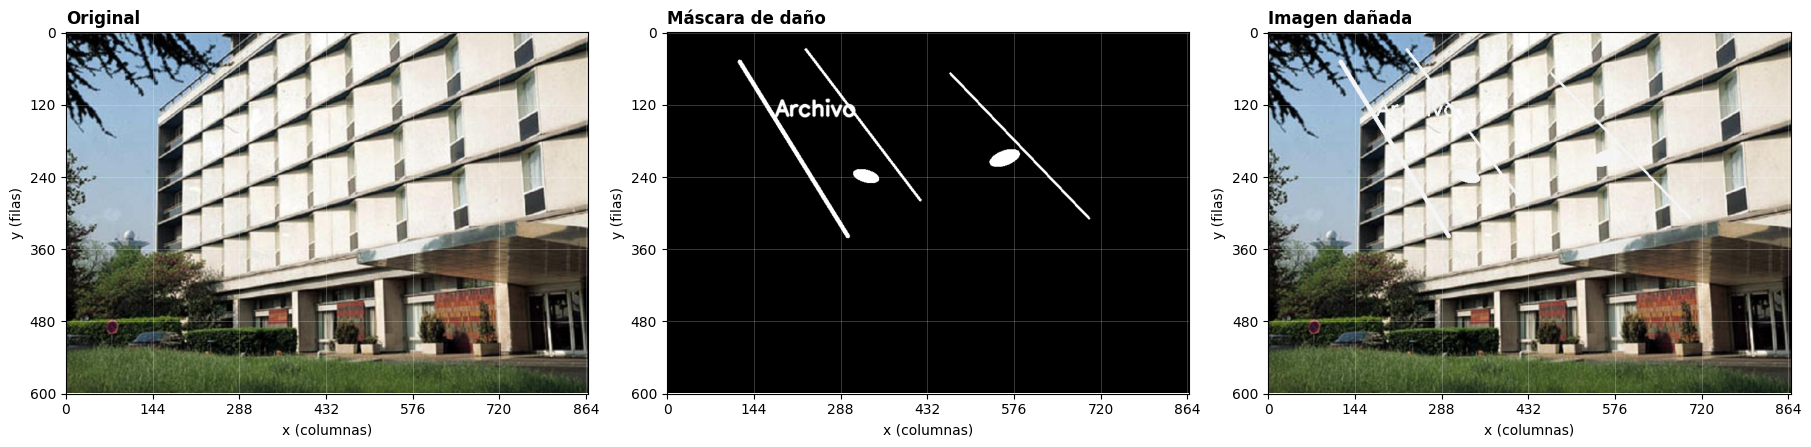

In [3]:
mascara_dano = crear_mascara_de_rayones(imagen_rgb)
imagen_danada = superponer_dano(imagen_rgb, mascara_dano)

x_region = 140
y_region = 80
ancho_region = 220
alto_region = 170

mostrar_varias_imagenes(
    [imagen_rgb, mascara_dano, imagen_danada],
    ["Original", "Máscara de daño", "Imagen dañada"],
    [None, "gray", None],
    tamano=(18, 5),
)


**Qué observar**

- La máscara marca exactamente las zonas que el algoritmo deberá reconstruir.
- La imagen dañada ya no tiene disponible la información original en esas regiones.

**Qué conclusión se puede sacar**

- El inpainting no trabaja “sobre la nada”: necesita que le indiquemos con precisión dónde está el daño.

**Qué limitación tiene este ejemplo**

- En una restauración real, conseguir una máscara buena puede ser una tarea tan difícil como la reconstrucción misma.


## 3. Automatización con Python: aplicar `cv2.inpaint`

Ahora sí vamos a usar los dos métodos principales de OpenCV.

- `cv2.INPAINT_TELEA`
- `cv2.INPAINT_NS`

Los dos reciben:

- la imagen dañada;
- la máscara binaria;
- un radio de inpainting;
- el método elegido.

Fijate que acá el punto importante no es solo correr la función, sino entender que el algoritmo intenta reconstruir información **plausible** alrededor del daño.


In [4]:
radio_inpainting = 3

restauracion_telea_bgr = cv2.inpaint(
    cv2.cvtColor(imagen_danada, cv2.COLOR_RGB2BGR),
    mascara_dano,
    radio_inpainting,
    cv2.INPAINT_TELEA,
)
restauracion_ns_bgr = cv2.inpaint(
    cv2.cvtColor(imagen_danada, cv2.COLOR_RGB2BGR),
    mascara_dano,
    radio_inpainting,
    cv2.INPAINT_NS,
)

restauracion_telea = cv2.cvtColor(restauracion_telea_bgr, cv2.COLOR_BGR2RGB)
restauracion_ns = cv2.cvtColor(restauracion_ns_bgr, cv2.COLOR_BGR2RGB)


Primero vamos a mirar una comparación global de resultados.


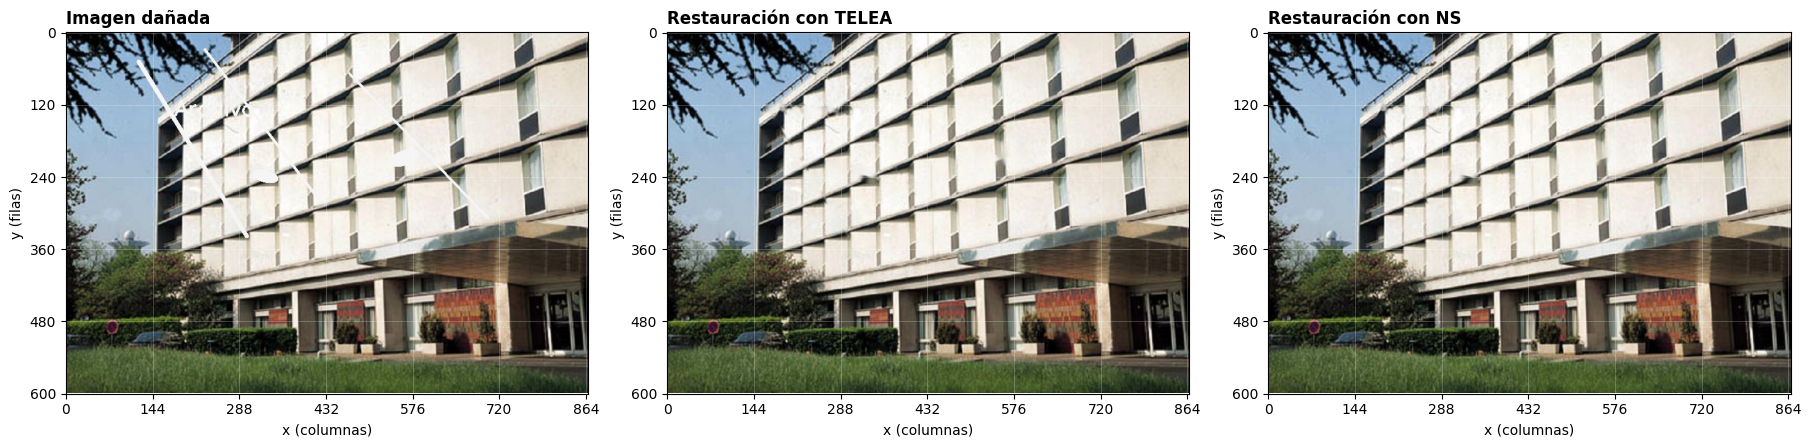

In [5]:
mostrar_varias_imagenes(
    [imagen_danada, restauracion_telea, restauracion_ns],
    ["Imagen dañada", "Restauración con TELEA", "Restauración con NS"],
    tamano=(18, 5),
)


**Qué observar**

- Ambos métodos intentan borrar rayones y marcas visibles.
- Algunas zonas quedan más naturales con un método que con el otro.

**Qué conclusión podés sacar**

- El inpainting no da un único resultado correcto. Cambia según la estructura visual alrededor del daño y según el método usado.

**Qué limitación tiene esta vista global**

- A escala completa muchas diferencias pasan desapercibidas. Para entender mejor el comportamiento de cada método conviene mirar un recorte local.


## 4. Reflexión guiada

[Pregunta para pensar]

Debajo del capó, estos algoritmos no “adivinan el pasado”. Lo que hacen es prolongar información disponible en el borde de la región dañada.

- Si una grieta corta una textura compleja, ¿qué tan confiable puede ser la reconstrucción?
- ¿Cuándo una restauración digital deja de ser reparación y empieza a ser reconstrucción interpretativa?
- Si el objetivo es archivo patrimonial, ¿qué debería quedar documentado sobre el proceso?


## 5. Ejemplo práctico: comparar una región local con detalle fino

Ahora vamos a recortar una región donde el daño cruza líneas y bordes arquitectónicos. Ese tipo de zona es ideal para ver si el algoritmo logra sostener continuidad o si produce artefactos visibles.


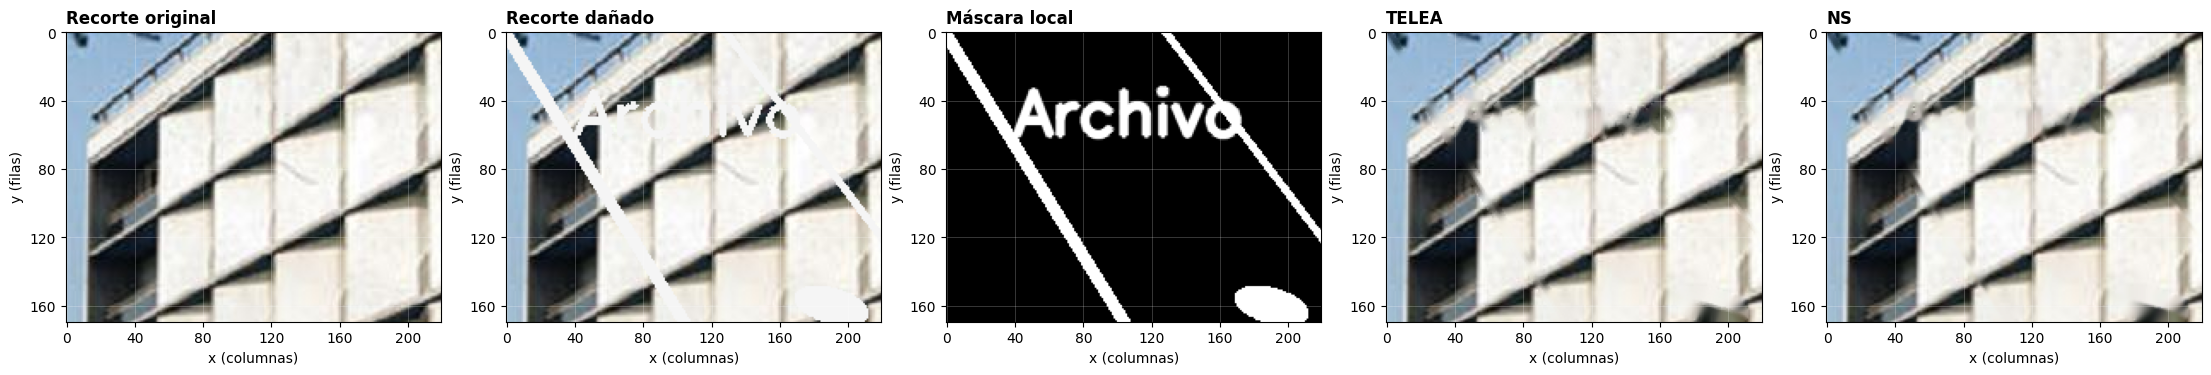

Error medio absoluto - TELEA: 0.27
Error medio absoluto - NS: 0.22


In [6]:
recorte_original = recortar_region(imagen_rgb, x_region, y_region, ancho_region, alto_region)
recorte_danado = recortar_region(imagen_danada, x_region, y_region, ancho_region, alto_region)
recorte_mascara = recortar_region(mascara_dano, x_region, y_region, ancho_region, alto_region)
recorte_telea = recortar_region(restauracion_telea, x_region, y_region, ancho_region, alto_region)
recorte_ns = recortar_region(restauracion_ns, x_region, y_region, ancho_region, alto_region)

mostrar_varias_imagenes(
    [recorte_original, recorte_danado, recorte_mascara, recorte_telea, recorte_ns],
    [
        "Recorte original",
        "Recorte dañado",
        "Máscara local",
        "TELEA",
        "NS",
    ],
    [None, None, "gray", None, None],
    tamano=(22, 5),
)

error_telea = calcular_error_medio_absoluto(imagen_rgb, restauracion_telea)
error_ns = calcular_error_medio_absoluto(imagen_rgb, restauracion_ns)

print(f"Error medio absoluto - TELEA: {error_telea:.2f}")
print(f"Error medio absoluto - NS: {error_ns:.2f}")


**Qué observar**

- En el recorte se ve mejor si las líneas y bordes siguen una continuidad creíble.
- La máscara local muestra exactamente dónde el algoritmo tuvo que inventar información.

**Qué conclusión se puede sacar**

- Un resultado plausible puede verse bien en tamaño completo y, sin embargo, fallar en detalle fino. Por eso conviene mirar regiones locales antes de dar por buena una restauración.

**Qué limitación tiene esta comparación**

- El error medio absoluto ayuda, pero no alcanza para decidir calidad patrimonial. Dos reconstrucciones con error parecido pueden diferir mucho en legibilidad o fidelidad visual.


## 6. Limitaciones y próximos pasos

El inpainting es potente, pero tiene límites claros:

- funciona mejor cuando el daño es relativamente pequeño respecto del contexto;
- puede fallar en texturas complejas o patrones geométricos muy estrictos;
- una restauración visualmente convincente no garantiza fidelidad histórica.

En un proyecto de restauración de archivo fotográfico, el inpainting conviene pensarlo como una herramienta más dentro de un pipeline, no como una solución automática y suficiente por sí sola.

## Actividad breve

Probá dos cambios y compará resultados:

1. aumentá el radio de inpainting a `5`;
2. agregá una nueva raya que atraviese otra región de la imagen.

Después respondé: **¿qué método te parece más estable para este caso y por qué?**

## Cierre

En este cuaderno usaste una máscara de daño para reconstruir zonas faltantes sobre una imagen real. Esto cierra un pequeño recorrido: limpiar ruido, limpiar máscaras y, finalmente, reparar regiones. Ese encadenamiento es muy cercano a lo que después vas a necesitar en un trabajo integrador de restauración.
